<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Mutation_Prediction_using_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_classification
import pandas as pd

In [3]:
# Generatie a synthetic dataset
X,y = make_classification(
    n_samples=1000,  # 1000 samples
    n_features=20,   #20 features
    n_informative=10, # 10 informative features
    n_redundant=5,   # 5 redundant features
    n_repeated=2, # 2 repeated features
    n_classes=2, # 2 Binary classification
    random_state=42  # For reproducibility
    )

# Convert to pandas Dataframe for better readability
df_features= pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df_target= pd.DataFrame(y,columns=['mutation_status'])

df = pd.concat([df_features, df_target], axis=1)
print("Dataset shape:",df.shape)
display(df.head())


Dataset shape: (1000, 21)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,mutation_status
0,-0.965971,-4.083222,0.742536,4.758031,3.862131,2.198416,-1.615355,0.971105,-0.812169,-1.615355,...,0.532418,4.464401,1.688499,3.862131,-1.450016,1.229877,0.669111,0.675820,0.121585,0
1,-0.081634,0.697994,1.804714,1.501068,1.093509,0.317548,-0.535982,1.993888,-0.366603,-0.535982,...,-0.236098,2.235500,0.296276,1.093509,1.152251,-3.163869,-1.481827,-1.938014,3.883104,1
2,-0.571736,0.765453,0.111636,4.269736,1.280064,0.398235,2.611323,-0.262405,1.762473,2.611323,...,1.312471,0.437786,0.615634,1.280064,1.307135,-0.039836,-3.290545,0.027699,-1.535882,1
3,-0.730813,2.170382,-4.472493,-1.883337,-1.978719,-0.785772,-3.071837,0.757920,0.245292,-3.071837,...,0.175835,-1.170256,0.294323,-1.978719,0.087357,0.043611,0.189531,-0.673849,-1.595267,0
4,0.755185,0.469361,0.773533,0.121682,0.201814,1.765667,0.225088,0.817219,1.084478,0.225088,...,-2.468933,-0.934296,0.233255,0.201814,1.110753,-1.595172,1.052310,-1.601653,0.922307,0


In [4]:
# 2 Data Splitting

from sklearn.model_selection import train_test_split

# Define features (X) and target(y)
X = df.drop('mutation_status',axis =1)
y = df['mutation_status']

# Split the data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (700, 20)
X_test shape: (300, 20)
y_train shape: (700,)
y_test shape: (300,)


In [5]:
# 3 Train a Random Forest Classifier
# Intitalize the Random Forest Classifier
# n_estimators: The number of trees in the forest
# random_state: Controls the randomnes of the bootstrapping of the sampels and featrues


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

rf_classifier = RandomForestClassifier(n_estimators=100,random_state=42)

# Fit the classifier to the training data (Tain the model)
rf_classifier.fit(X_train,y_train)
print("Random Forest Classifier trained successfully")


Random Forest Classifier trained successfully


Accuracy:,0.9167
Precision:,0.9085
Recall:,0.9267
F1 Score:,0.9175

 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       150
           1       0.91      0.93      0.92       150

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



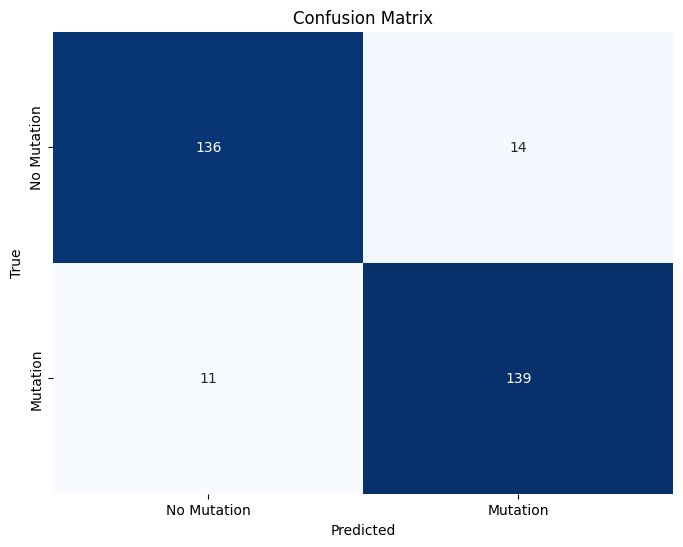

In [8]:
# 4 Evalaute the model
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, classification_report,confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
# Make predicitons on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print(f"Accuracy:,{accuracy:.4f}")
print(f"Precision:,{precision:.4f}")
print(f"Recall:,{recall:.4f}")
print(f"F1 Score:,{f1:.4f}")
print("\n Classification Report:")
print(classification_report(y_test,y_pred))

# Display Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues', cbar = False,
            xticklabels=['No Mutation','Mutation'],
            yticklabels=['No Mutation','Mutation'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()





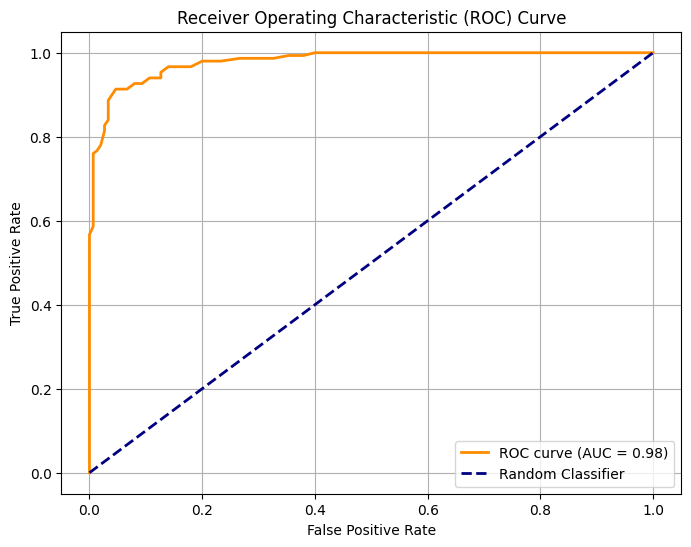

In [12]:
# ROC Curve and AUC Score
from sklearn.metrics import roc_curve,roc_auc_score

# Get probabilites for the positive class (calss 1- mutation)
y_pred_proba = rf_classifier.predict_proba(X_test)[:,1]

# Calculate the ROC Curve
fpr,tpr,thresholds = roc_curve(y_test,y_pred_proba)

# Calcualte AUC Score
auc_score = roc_auc_score(y_test,y_pred_proba)
#Plot the ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color = 'darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--',label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()